# Análisis de Umbrales de Saldo y Morosidad — WK3

**Equipo:** Equip_32 — Analistas de Finanzas y Riesgo Crediticio  
**Dataset:** `2026-07-13_3_bank_dataset_transformed.csv`

---

## 1. Introducción

### 1.1 Objetivo del análisis

Identificar **umbrales de saldo** que puedan indicar un mayor riesgo de **morosidad** en la cartera de clientes, con el fin de apoyar las políticas de concesión y monitorización del departamento de Riesgo Crediticio.

### 1.2 Pregunta de negocio

> **¿Qué umbrales de saldo podrían indicar un mayor riesgo de morosidad?**

### 1.3 Metodología analítica

El notebook sigue un proceso analítico estructurado que conecta el entendimiento del negocio con evidencia estadística y modelización:

```
Business Understanding
        ↓
       EDA
        ↓
Validación estadística
        ↓
   Modelización
        ↓
  Conclusiones
        ↓
Recomendaciones
```

1. **Business Understanding:** Definición de la pregunta y variables clave (Saldo, Morosidad, Perfil crediticio).
2. **EDA:** Análisis descriptivo para contextualizar la cartera.
3. **Investigación analítica:** Contrastes estadísticos, quintiles, regresión logística y árboles de decisión para detectar umbrales.
4. **Validación estadística:** Chi-cuadrado sobre los intervalos identificados.
5. **Conclusiones y recomendaciones:** Respuesta directa y acciones para Riesgo Crediticio.


## 2. Preparación de datos


### 2.1 Importación de librerías


In [52]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LogisticRegression


### 2.2 Configuración global


In [53]:
# Estilo visual del proyecto (referencia WK2)
sns.set_theme(style="white")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.left"] = True
plt.rcParams["axes.spines.bottom"] = True
plt.rcParams["axes.linewidth"] = 1.2

COLORS = ["#1F5C45", "#4F8A6A", "#8DB79A", "#AAD7B8", "#DDEFE6", "#C8E2D5"]
PALETTE_MOROSIDAD = {"no": "#8DB79A", "yes": "#1F5C45"}

BALANCE_BINS_STANDARD = [-np.inf, 0, 500, 1500, 3000, np.inf]
BALANCE_LABELS_STANDARD = [
    "Negativo (≤ €0)", "€0–500", "€500–1.500", "€1.500–3.000", "> €3.000"
]
SEGMENT_COLORS = dict(zip(BALANCE_LABELS_STANDARD, COLORS[:5]))

CREDIT_PROFILE_ORDER = [
    "Sin productos de crédito",
    "Solo hipoteca",
    "Solo préstamo personal",
    "Hipoteca + préstamo personal",
]


### 2.3 Carga del dataset

Se carga únicamente el dataset transformado de WK3. La columna `default` se renombra a **Morosidad** para alinear la nomenclatura con el negocio.


In [54]:
DATA_PATH = Path("../Data/2026-07-13_3_bank_dataset_transformed.csv")

df_raw = pd.read_csv(DATA_PATH)
df_raw = df_raw.rename(columns={"default": "Morosidad"})

print(f"Registros cargados: {len(df_raw):,}")
df_raw[["id", "balance", "Morosidad", "housing", "loan"]].head()


Registros cargados: 10,975


,id,balance,Morosidad,housing,loan
0,1,2343,no,yes,no
1,2,45,no,no,no
2,3,1270,no,yes,no
3,4,2476,no,yes,no
4,5,184,no,no,no


### 2.4 Variables derivadas


In [55]:
def morosidad_rate_table(data, group_col):
    """Resumen de tasa de morosidad por columna de agrupación."""
    summary = (
        data.groupby(group_col, observed=True)
        .agg(clientes=("morosidad_flag", "count"),
             casos_morosidad=("morosidad_flag", "sum"),
             tasa_morosidad=("morosidad_flag", "mean"))
        .reset_index()
    )
    summary["tasa_morosidad_pct"] = (summary["tasa_morosidad"] * 100).round(2)
    return summary


def cross_morosidad_rate(data, row_col, col_col):
    """Tablas pivote de tasas de morosidad y tamaños muestrales."""
    grouped = (
        data.groupby([row_col, col_col], observed=True)
        .agg(tasa_morosidad=("morosidad_flag", "mean"), n=("morosidad_flag", "count"))
        .reset_index()
    )
    pivot_rate = grouped.pivot(index=row_col, columns=col_col, values="tasa_morosidad")
    pivot_n = grouped.pivot(index=row_col, columns=col_col, values="n")
    return pivot_rate, pivot_n


def assign_credit_profile(data):
    """Perfil crediticio a partir de housing y loan (criterio WK2)."""
    conditions = [
        (data["housing"] == "no") & (data["loan"] == "no"),
        (data["housing"] == "yes") & (data["loan"] == "no"),
        (data["housing"] == "no") & (data["loan"] == "yes"),
        (data["housing"] == "yes") & (data["loan"] == "yes"),
    ]
    return pd.Series(
        np.select(conditions, CREDIT_PROFILE_ORDER, default="Desconocido"),
        index=data.index, dtype=str,
    )


def annotate_bars(ax, fmt="{:.1f}", suffix="", inside=True):
    """Etiquetas en barras con color de texto adaptativo."""
    for bar in ax.patches:
        h = bar.get_height()
        if h <= 0 or np.isnan(h):
            continue
        fc = bar.get_facecolor()
        lum = 0.299 * fc[0] + 0.587 * fc[1] + 0.114 * fc[2]
        txt_color = "white" if lum < 0.55 else "#333333"
        label = fmt.format(h) + suffix
        ylim = ax.get_ylim()[1] or 1
        if inside and h > ylim * 0.05:
            ax.text(bar.get_x() + bar.get_width() / 2, h * 0.5, label,
                    ha="center", va="center", fontsize=11, fontweight="bold", color=txt_color)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, h + ylim * 0.01, label,
                    ha="center", va="bottom", fontsize=11, fontweight="bold", color="#333333")


def extract_tree_thresholds(tree):
    """Extrae umbrales de saldo de un árbol de decisión entrenado."""
    return sorted(set(round(t, 1) for t in tree.tree_.threshold if t != -2))


def train_threshold_tree(data, max_depth=3, min_samples_leaf=30):
    """Entrena árbol de decisión para identificar puntos de corte del saldo."""
    tree = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",
        random_state=42,
    )
    tree.fit(data[["balance"]], data["morosidad_flag"])
    return tree


# --- Variables derivadas ---
df = df_raw[["id", "balance", "Morosidad", "housing", "loan"]].copy()
df["morosidad_flag"] = (df["Morosidad"] == "yes").astype(int)
df["credit_profile"] = assign_credit_profile(df)
df["balance_segment"] = pd.cut(
    df["balance"], bins=BALANCE_BINS_STANDARD, labels=BALANCE_LABELS_STANDARD
)

PORTFOLIO_MEAN_BALANCE = df["balance"].mean()
PORTFOLIO_MOROSIDAD_RATE = df["morosidad_flag"].mean() * 100

print(f"Muestra: {len(df):,} clientes")
print(f"Saldo medio del portfolio: €{PORTFOLIO_MEAN_BALANCE:,.2f}")
print(f"Tasa global de morosidad: {PORTFOLIO_MOROSIDAD_RATE:.2f}%")
print(f"Casos de morosidad: {df['morosidad_flag'].sum()}")


Muestra: 10,975 clientes
Saldo medio del portfolio: €1,539.15
Tasa global de morosidad: 1.47%
Casos de morosidad: 161


## 3. Análisis descriptivo

Este bloque contextualiza la cartera antes de la investigación analítica. No extrae conclusiones sobre umbrales; únicamente describe la distribución de clientes, saldo y morosidad por perfil crediticio.


### 3.1 Distribución de clientes por perfil crediticio


In [56]:
profile_counts = (
    df["credit_profile"]
    .value_counts()
    .reindex(CREDIT_PROFILE_ORDER)
    .rename_axis("Perfil crediticio")
    .reset_index(name="clientes")
)
profile_counts["pct_cartera"] = (
    profile_counts["clientes"] / profile_counts["clientes"].sum() * 100
).round(2)

print("Tabla 3.1 — Distribución de clientes por perfil crediticio")
display(profile_counts)


Tabla 3.1 — Distribución de clientes por perfil crediticio


,Perfil crediticio,clientes,pct_cartera
0,Sin productos de crédito,5185,47.24
1,Solo hipoteca,4363,39.75
2,Solo préstamo personal,609,5.55
3,Hipoteca + préstamo personal,818,7.45


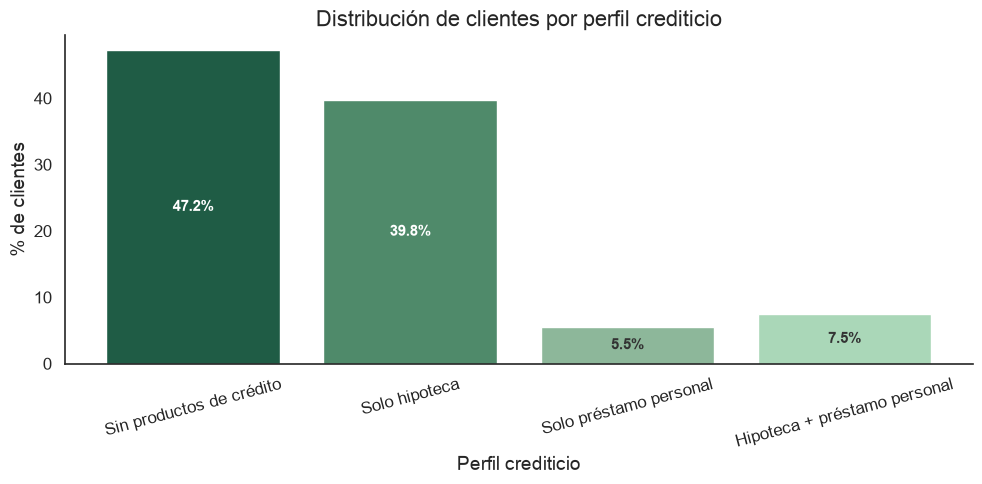

In [57]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(profile_counts["Perfil crediticio"], profile_counts["pct_cartera"],
       color=COLORS[:4], edgecolor="white")
ax.set_title("Distribución de clientes por perfil crediticio")
ax.set_xlabel("Perfil crediticio")
ax.set_ylabel("% de clientes")
ax.tick_params(axis="x", rotation=15)
annotate_bars(ax, fmt="{:.1f}", suffix="%")
plt.tight_layout()
plt.show()


### 3.2 Saldo medio y tasa de morosidad por perfil crediticio


In [58]:
profile_summary = (
    df.groupby("credit_profile", observed=True)
    .agg(
        clientes=("morosidad_flag", "count"),
        casos_morosidad=("morosidad_flag", "sum"),
        saldo_medio=("balance", "mean"),
        tasa_morosidad=("morosidad_flag", "mean"),
    )
    .reindex(CREDIT_PROFILE_ORDER)
    .round(2)
)
profile_summary["tasa_morosidad_pct"] = (profile_summary["tasa_morosidad"] * 100).round(2)

print("Tabla 3.2 — Saldo medio y morosidad por perfil crediticio")
display(profile_summary)


Tabla 3.2 — Saldo medio y morosidad por perfil crediticio


,clientes,casos_morosidad,saldo_medio,tasa_morosidad,tasa_morosidad_pct
credit_profile,,,,,
Sin productos de crédito,5185,45,1878.88,0.01,1.0
Solo hipoteca,4363,61,1365.92,0.01,1.0
Solo préstamo personal,609,33,917.11,0.05,5.0
Hipoteca + préstamo personal,818,22,772.79,0.03,3.0


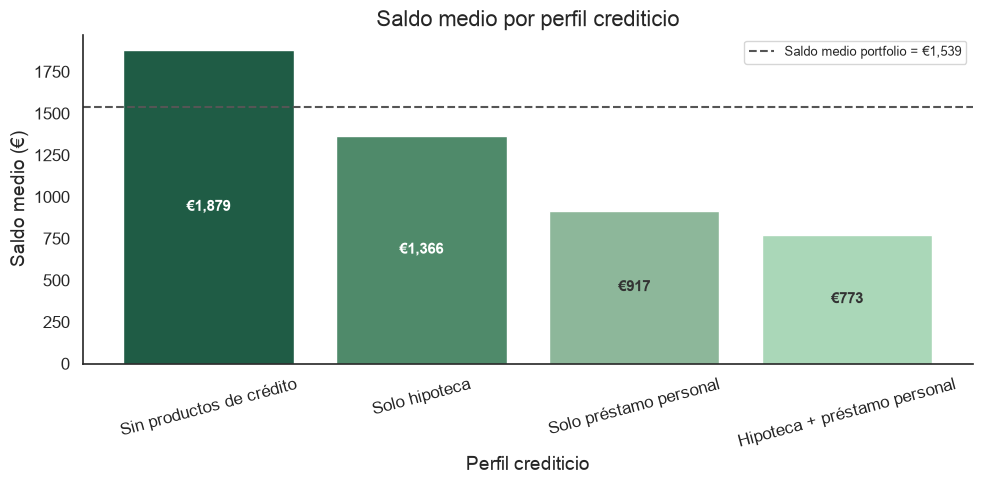

In [59]:
# Gráfico 1: Saldo medio
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(profile_summary.index, profile_summary["saldo_medio"],
       color=COLORS[:4], edgecolor="white")
ax.axhline(PORTFOLIO_MEAN_BALANCE, color="#555555", linestyle="--", linewidth=1.5,
           label=f"Saldo medio portfolio = €{PORTFOLIO_MEAN_BALANCE:,.0f}")
ax.set_title("Saldo medio por perfil crediticio")
ax.set_xlabel("Perfil crediticio")
ax.set_ylabel("Saldo medio (€)")
ax.tick_params(axis="x", rotation=15)
ax.legend(fontsize=9)
annotate_bars(ax, fmt="€{:,.0f}", suffix="")
plt.tight_layout()
plt.show()


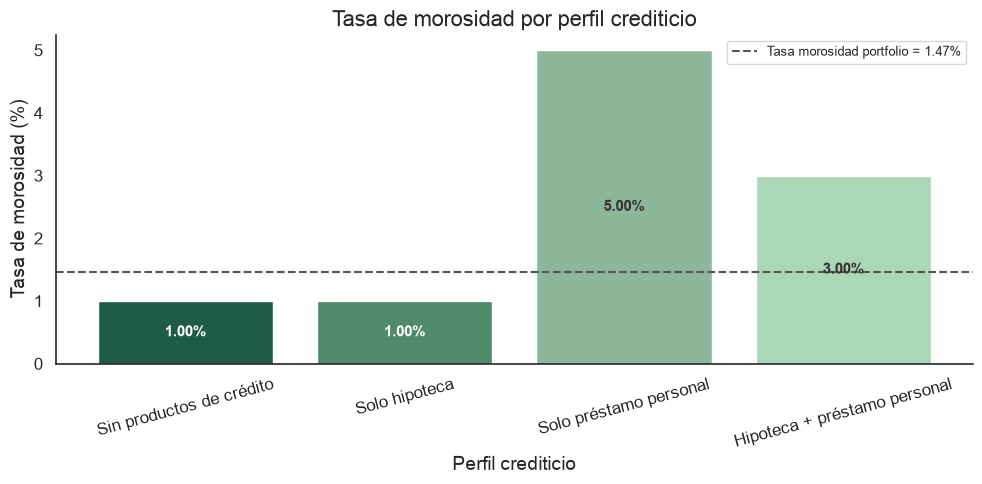

In [60]:
# Gráfico 2: Tasa de morosidad
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(profile_summary.index, profile_summary["tasa_morosidad_pct"],
       color=COLORS[:4], edgecolor="white")
ax.axhline(PORTFOLIO_MOROSIDAD_RATE, color="#555555", linestyle="--", linewidth=1.5,
           label=f"Tasa morosidad portfolio = {PORTFOLIO_MOROSIDAD_RATE:.2f}%")
ax.set_title("Tasa de morosidad por perfil crediticio")
ax.set_xlabel("Perfil crediticio")
ax.set_ylabel("Tasa de morosidad (%)")
ax.tick_params(axis="x", rotation=15)
ax.legend(fontsize=9)
annotate_bars(ax, fmt="{:.2f}", suffix="%")
plt.tight_layout()
plt.show()


### 3.3 Tasa de morosidad por perfil crediticio × segmento de saldo


In [61]:
cross_rate, cross_n = cross_morosidad_rate(df, "credit_profile", "balance_segment")
cross_rate = cross_rate.reindex(index=CREDIT_PROFILE_ORDER, columns=BALANCE_LABELS_STANDARD)
cross_pct = (cross_rate * 100).round(2)

print("Tabla 3.3 — Tasa de morosidad (%) por perfil crediticio × segmento de saldo")
display(cross_pct)
print("\nTamaños muestrales:")
display(cross_n.reindex(index=CREDIT_PROFILE_ORDER, columns=BALANCE_LABELS_STANDARD).astype("Int64"))


Tabla 3.3 — Tasa de morosidad (%) por perfil crediticio × segmento de saldo


balance_segment,Negativo (≤ €0),€0–500,€500–1.500,€1.500–3.000,> €3.000
credit_profile,,,,,
Sin productos de crédito,4.47,1.22,0.24,0.00,0.00
Solo hipoteca,6.60,0.84,0.37,0.19,0.18
Solo préstamo personal,19.33,3.10,1.53,0.00,0.00
Hipoteca + préstamo personal,6.97,2.46,0.50,0.00,0.00



Tamaños muestrales:


balance_segment,Negativo (≤ €0),€0–500,€500–1.500,€1.500–3.000,> €3.000
credit_profile,,,,,
Sin productos de crédito,470,1726,1238,855,896
Solo hipoteca,636,1543,1089,526,569
Solo préstamo personal,119,258,131,58,43
Hipoteca + préstamo personal,201,285,200,77,55


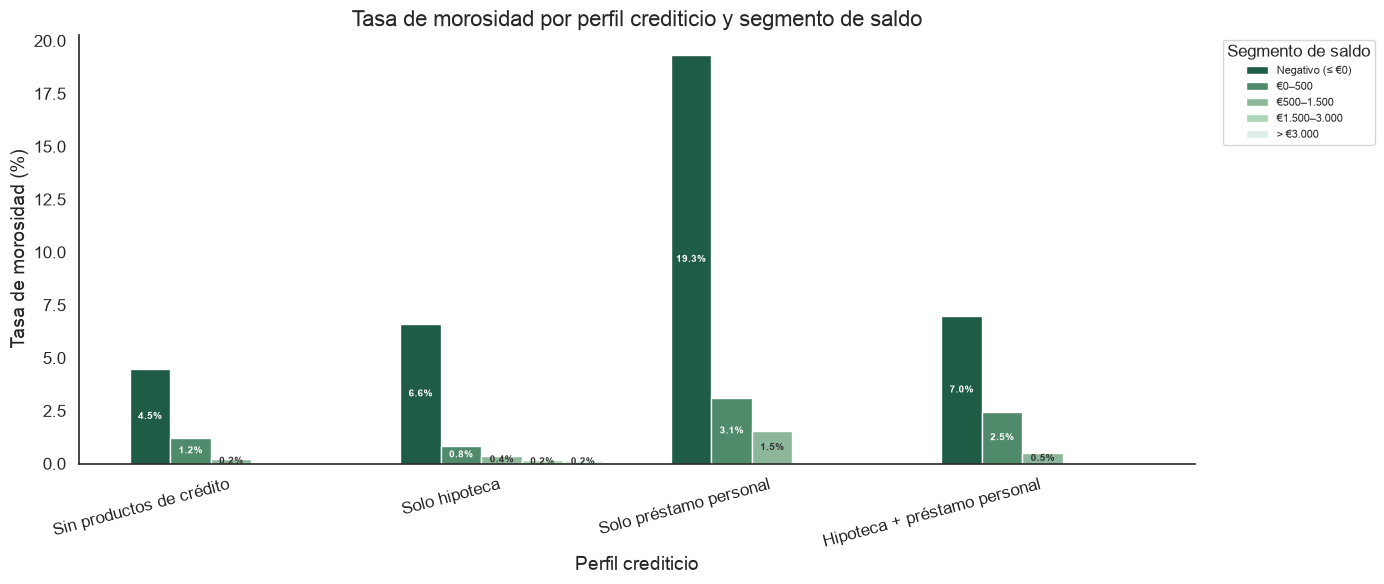

In [62]:
plot_df = cross_pct.reset_index().melt(id_vars="credit_profile", var_name="segmento", value_name="tasa")
plot_df = plot_df.dropna(subset=["tasa"])

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(CREDIT_PROFILE_ORDER))
width = 0.15

for i, seg in enumerate(BALANCE_LABELS_STANDARD):
    vals = cross_pct[seg].values if seg in cross_pct.columns else np.zeros(len(CREDIT_PROFILE_ORDER))
    bars = ax.bar(x + i * width, vals, width, label=seg, color=SEGMENT_COLORS[seg], edgecolor="white")
    for bar, val in zip(bars, vals):
        if not np.isnan(val) and val > 0:
            fc = bar.get_facecolor()
            lum = 0.299 * fc[0] + 0.587 * fc[1] + 0.114 * fc[2]
            tc = "white" if lum < 0.55 else "#333333"
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, f"{val:.1f}%",
                    ha="center", va="center", fontsize=7, fontweight="bold", color=tc)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(CREDIT_PROFILE_ORDER, rotation=15, ha="right")
ax.set_title("Tasa de morosidad por perfil crediticio y segmento de saldo")
ax.set_xlabel("Perfil crediticio")
ax.set_ylabel("Tasa de morosidad (%)")
ax.legend(title="Segmento de saldo", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## 4. Investigación analítica

Núcleo del notebook. Cada apartado responde una pregunta concreta y conduce al siguiente hasta identificar los umbrales de saldo relevantes para la morosidad.


## 4.1 ¿Existe realmente relación entre el saldo y la morosidad?


### 1. Pregunta de investigación

¿Existe una relación estadísticamente detectable entre el **Saldo** (`balance`) de la cuenta y la **Morosidad** del cliente?

### 2. Justificación analítica

Antes de buscar umbrales concretos, es necesario confirmar que ambas variables están relacionadas. Si no lo estuvieran, los puntos de corte carecerían de sentido analítico. Se combinan estadísticos descriptivos, visualizaciones y pruebas no paramétricas (Mann–Whitney U) y correlación punto-biserial, adecuadas para una variable continua y una binaria con distribución asimétrica.


### 3. Código


In [63]:
# Estadísticos descriptivos por Morosidad
desc = df.groupby("Morosidad")["balance"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)
desc.index.name = "Morosidad"

print("Tabla 4.1a — Estadísticos descriptivos del saldo por Morosidad")
display(desc)


Tabla 4.1a — Estadísticos descriptivos del saldo por Morosidad


,count,mean,median,std,min,max
Morosidad,,,,,,
no,10814,1563.13,568.0,3257.85,-3058,81204
yes,161,-71.44,0.0,838.73,-6847,5249


### 4. Tabla de resultados


In [64]:
# Mann–Whitney U
g_no = df.loc[df["morosidad_flag"] == 0, "balance"]
g_si = df.loc[df["morosidad_flag"] == 1, "balance"]
u_stat, p_mw = stats.mannwhitneyu(g_no, g_si, alternative="two-sided")

# Correlación punto-biserial
r_pb, p_pb = stats.pointbiserialr(df["balance"], df["morosidad_flag"])

results_41 = pd.DataFrame([
    {"Test": "Mann–Whitney U", "Estadístico": f"{u_stat:,.0f}", "p-value": f"{p_mw:.2e}",
     "Interpretación": "Diferencia significativa" if p_mw < 0.05 else "Sin diferencia"},
    {"Test": "Correlación punto-biserial", "Estadístico": f"r = {r_pb:.4f}", "p-value": f"{p_pb:.2e}",
     "Interpretación": "Correlación significativa" if p_pb < 0.05 else "Sin correlación"},
])
print("Tabla 4.1b — Resultados de pruebas estadísticas")
display(results_41)


Tabla 4.1b — Resultados de pruebas estadísticas


,Test,Estadístico,p-value,Interpretación
0,Mann–Whitney U,"1,488,046",4.97e-54,Diferencia significativa
1,Correlación punto-biserial,r = -0.0606,2.06e-10,Correlación significativa


### 5. Visualización


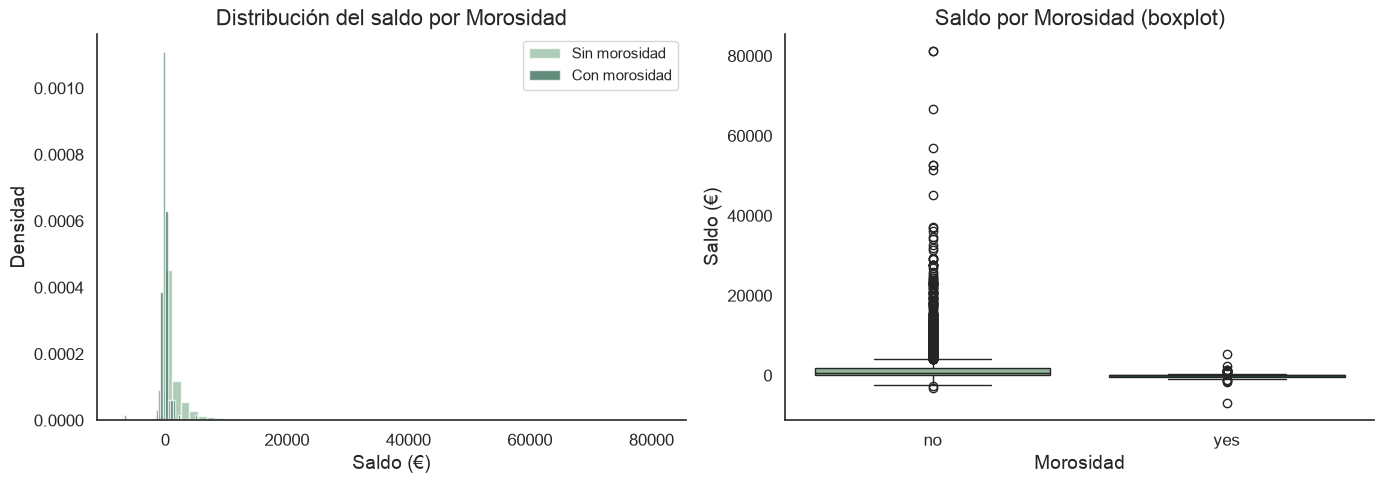

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(g_no, bins=60, alpha=0.7, color=COLORS[2], label="Sin morosidad", density=True)
axes[0].hist(g_si, bins=30, alpha=0.7, color=COLORS[0], label="Con morosidad", density=True)
axes[0].set_title("Distribución del saldo por Morosidad")
axes[0].set_xlabel("Saldo (€)")
axes[0].set_ylabel("Densidad")
axes[0].legend()

# Boxplot
sns.boxplot(data=df, x="Morosidad", y="balance", palette=PALETTE_MOROSIDAD,
            hue="Morosidad", legend=False, ax=axes[1])
axes[1].set_title("Saldo por Morosidad (boxplot)")
axes[1].set_xlabel("Morosidad")
axes[1].set_ylabel("Saldo (€)")

plt.tight_layout()
plt.show()


### 6. Interpretación estadística

- El saldo medio de clientes **con morosidad** (€−71) es sustancialmente inferior al de clientes **sin morosidad** (€1.563).
- **Mann–Whitney U** (p < 0,001): se rechaza que ambas distribuciones sean iguales.
- **Correlación punto-biserial** (r = −0,061; p < 0,001): relación negiva débil pero estadísticamente significativa — a menor saldo, mayor probabilidad de morosidad.

### 7. Interpretación de negocio

La morosidad se concentra en clientes con saldos bajos o negativos. Existe base empírica para investigar **umbrales operativos** del saldo como señales de alerta temprana.

### 8. Conclusión del bloque

**Sí existe relación** entre saldo y morosidad. Procede analizar cómo evoluciona el riesgo a lo largo del espectro de saldos.


## 4.2 ¿Cómo evoluciona el riesgo de morosidad a medida que cambia el saldo?


### 1. Pregunta de investigación

¿Cómo varía la tasa de morosidad al segmentar el saldo en **quintiles** y modelizar la relación mediante **regresión logística**?

### 2. Justificación analítica

Los quintiles permiten observar la evolución del riesgo sin imponer umbrales a priori. La regresión logística complementa este análisis proporcionando una curva de probabilidad continua que facilita identificar la tendencia general saldo → morosidad.


### 3. Código


In [66]:
df["balance_quintile"] = pd.qcut(df["balance"], q=5, duplicates="drop")
quintile_rates = morosidad_rate_table(df, "balance_quintile")
quintile_rates["rango_saldo"] = quintile_rates["balance_quintile"].astype(str)

print("Tabla 4.2 — Tasa de morosidad por quintil de saldo")
display(quintile_rates[["balance_quintile", "clientes", "casos_morosidad", "tasa_morosidad_pct"]])


Tabla 4.2 — Tasa de morosidad por quintil de saldo


,balance_quintile,clientes,casos_morosidad,tasa_morosidad_pct
0,"(-6847.001, 65.0]",2198,121,5.51
1,"(65.0, 341.0]",2199,25,1.14
2,"(341.0, 871.4]",2188,5,0.23
3,"(871.4, 2235.8]",2195,8,0.36
4,"(2235.8, 81204.0]",2195,2,0.09


### 4. Tabla de resultados


In [67]:
# Regresión logística
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(df[["balance"]], df["morosidad_flag"])

print("Tabla 4.2b — Coeficientes regresión logística")
coef_table = pd.DataFrame({
    "Variable": ["balance (Saldo)"],
    "Coeficiente": [log_reg.coef_[0][0]],
    "Intercepto": [log_reg.intercept_[0]],
})
display(coef_table.round(6))
print(f"\nCoeficiente negativo → a mayor saldo, menor log-odds de morosidad.")


Tabla 4.2b — Coeficientes regresión logística


,Variable,Coeficiente,Intercepto
0,balance (Saldo),-0.002014,-3.495508



Coeficiente negativo → a mayor saldo, menor log-odds de morosidad.


### 5. Visualización


/Users/rogerdefez/Documents/Cursos i Llibres/BootCamp IT Academy/04_Simulador/ProjecteData/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


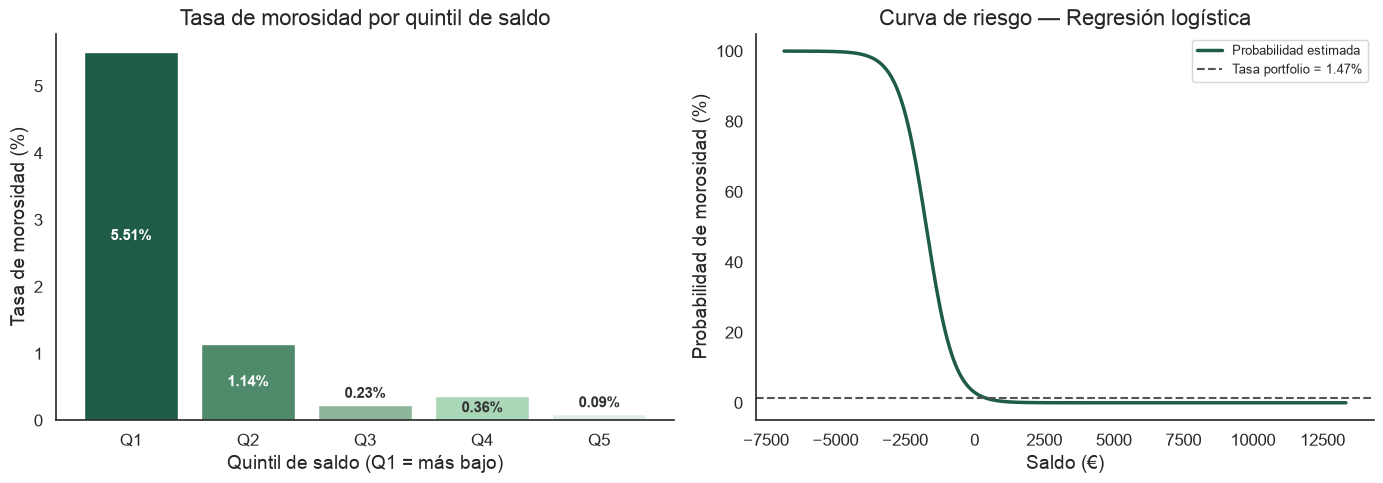

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras por quintil
ax = axes[0]
labels = [str(q) for q in quintile_rates["balance_quintile"]]
ax.bar(range(len(quintile_rates)), quintile_rates["tasa_morosidad_pct"],
       color=COLORS[:len(quintile_rates)], edgecolor="white")
ax.set_xticks(range(len(quintile_rates)))
ax.set_xticklabels([f"Q{i+1}" for i in range(len(quintile_rates))])
ax.set_title("Tasa de morosidad por quintil de saldo")
ax.set_xlabel("Quintil de saldo (Q1 = más bajo)")
ax.set_ylabel("Tasa de morosidad (%)")
annotate_bars(ax, fmt="{:.2f}", suffix="%")

# Curva logística
ax = axes[1]
x_range = np.linspace(df["balance"].min(), df["balance"].quantile(0.99), 300).reshape(-1, 1)
y_prob = log_reg.predict_proba(x_range)[:, 1] * 100
ax.plot(x_range, y_prob, color=COLORS[0], linewidth=2.5, label="Probabilidad estimada")
ax.axhline(PORTFOLIO_MOROSIDAD_RATE, color="#555555", linestyle="--",
           label=f"Tasa portfolio = {PORTFOLIO_MOROSIDAD_RATE:.2f}%")
ax.set_title("Curva de riesgo — Regresión logística")
ax.set_xlabel("Saldo (€)")
ax.set_ylabel("Probabilidad de morosidad (%)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### 6. Interpretación estadística

| Quintil | Tasa morosidad (%) |
|---|---:|
| Q1 (saldo más bajo) | 5,51 |
| Q2 | 1,14 |
| Q3 | 0,23 |
| Q4 | 0,36 |
| Q5 (saldo más alto) | 0,09 |

La tasa cae de **5,51%** (Q1) a **0,09%** (Q5). La regresión logística confirma coeficiente **negativo** (−0,002): la probabilidad de morosidad decrece al aumentar el saldo.

### 7. Interpretación de negocio

El riesgo no es lineal: se concentra en el **20% inferior** de saldos. A partir del tercer quintil (~€871), la morosidad cae por debajo del **0,4%**, muy inferior a la media del portfolio (1,47%).

### 8. Conclusión del bloque

Existe un **gradiente claro** de riesgo decreciente con el saldo. El siguiente paso es identificar los **puntos de ruptura** concretos dentro de ese gradiente.


## 4.3 ¿Dónde aparecen los puntos de ruptura (umbrales)?


### 1. Pregunta de investigación

¿Qué **umbrales de saldo** separan segmentos con distinto riesgo de morosidad?

### 2. Justificación analítica

Un **árbol de decisión** (profundidad 2–3) permite identificar automáticamente puntos de corte en `balance` sin pretender clasificar clientes. Con `class_weight='balanced'` se compensa el desbalance de la Morosidad (1,47%) para que el árbol detecte zonas de mayor riesgo.


### 3. Código


In [69]:
tree_global = train_threshold_tree(df, max_depth=3, min_samples_leaf=30)
thresholds_global = extract_tree_thresholds(tree_global)

print("Estructura del árbol de decisión (referencia):")
print(export_text(tree_global, feature_names=["balance"]))

thresholds_df = pd.DataFrame({
    "Umbral (€)": thresholds_global,
    "vs Saldo medio portfolio (€)": [round(t - PORTFOLIO_MEAN_BALANCE, 1) for t in thresholds_global],
})
thresholds_df["Posición relativa"] = thresholds_df["Umbral (€)"].apply(
    lambda x: "Por debajo" if x < PORTFOLIO_MEAN_BALANCE else "Por encima"
)

print("\nTabla 4.3 — Umbrales identificados por el árbol de decisión")
display(thresholds_df)


Estructura del árbol de decisión (referencia):
|--- balance <= 105.50
|   |--- balance <= -0.50
|   |   |--- balance <= -336.50
|   |   |   |--- class: 1
|   |   |--- balance >  -336.50
|   |   |   |--- class: 1
|   |--- balance >  -0.50
|   |   |--- balance <= 17.50
|   |   |   |--- class: 1
|   |   |--- balance >  17.50
|   |   |   |--- class: 1
|--- balance >  105.50
|   |--- balance <= 1415.00
|   |   |--- balance <= 339.50
|   |   |   |--- class: 0
|   |   |--- balance >  339.50
|   |   |   |--- class: 0
|   |--- balance >  1415.00
|   |   |--- balance <= 2404.50
|   |   |   |--- class: 0
|   |   |--- balance >  2404.50
|   |   |   |--- class: 0


Tabla 4.3 — Umbrales identificados por el árbol de decisión


,Umbral (€),vs Saldo medio portfolio (€),Posición relativa
0,-336.5,-1875.6,Por debajo
1,-0.5,-1539.6,Por debajo
2,17.5,-1521.6,Por debajo
3,105.5,-1433.6,Por debajo
4,339.5,-1199.6,Por debajo
5,1415.0,-124.1,Por debajo
6,2404.5,865.4,Por encima


### 4. Tabla de resultados


In [70]:
# Tasa de morosidad por encima/debajo de cada umbral principal
KEY_THRESHOLDS = [-0.5, 105.5, 339.5, 1415.0]
threshold_analysis = []
for th in KEY_THRESHOLDS:
    below = df[df["balance"] <= th]
    above = df[df["balance"] > th]
    threshold_analysis.append({
        "Umbral (€)": th,
        "Tasa morosidad ≤ umbral (%)": round(below["morosidad_flag"].mean() * 100, 2),
        "Tasa morosidad > umbral (%)": round(above["morosidad_flag"].mean() * 100, 2),
        "Clientes ≤ umbral": len(below),
        "Clientes > umbral": len(above),
    })

threshold_rates = pd.DataFrame(threshold_analysis)
print("Tabla 4.3b — Morosidad por lado de cada umbral clave")
display(threshold_rates)


Tabla 4.3b — Morosidad por lado de cada umbral clave


,Umbral (€),Tasa morosidad ≤ umbral (%),Tasa morosidad > umbral (%),Clientes ≤ umbral,Clientes > umbral
0,-0.5,11.31,0.83,672,10303
1,105.5,5.12,0.35,2576,8399
2,339.5,3.33,0.23,4381,6594
3,1415.0,2.04,0.06,7795,3180


### 5. Visualización


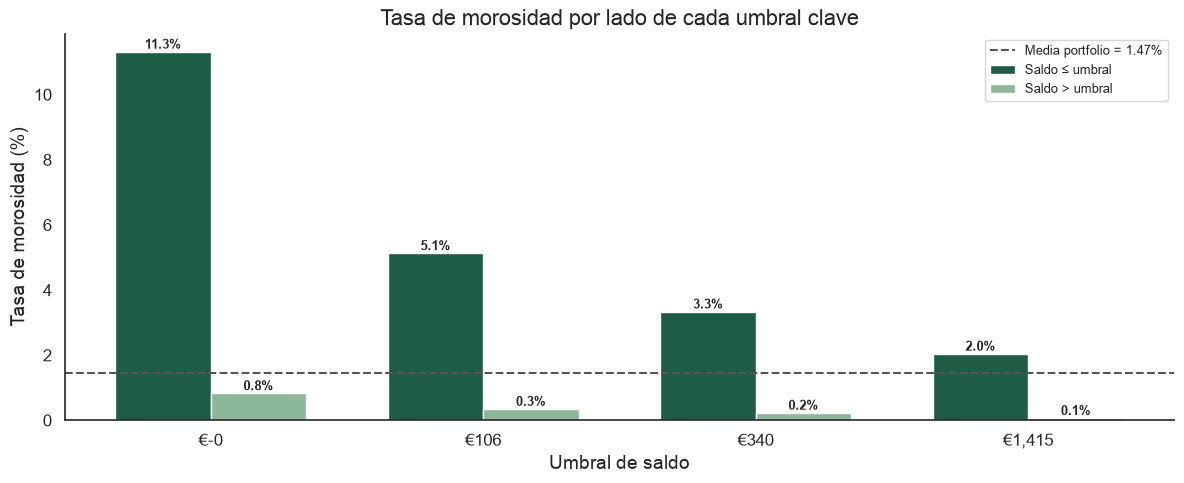

In [71]:
fig, ax = plt.subplots(figsize=(12, 5))

key_th = [t for t in KEY_THRESHOLDS if t in thresholds_global or True]
rates_below = [df[df["balance"] <= t]["morosidad_flag"].mean() * 100 for t in KEY_THRESHOLDS]
rates_above = [df[df["balance"] > t]["morosidad_flag"].mean() * 100 for t in KEY_THRESHOLDS]
x = np.arange(len(KEY_THRESHOLDS))
width = 0.35

ax.bar(x - width/2, rates_below, width, label="Saldo ≤ umbral", color=COLORS[0], edgecolor="white")
ax.bar(x + width/2, rates_above, width, label="Saldo > umbral", color=COLORS[2], edgecolor="white")
ax.axhline(PORTFOLIO_MOROSIDAD_RATE, color="#555555", linestyle="--",
           label=f"Media portfolio = {PORTFOLIO_MOROSIDAD_RATE:.2f}%")
ax.set_xticks(x)
ax.set_xticklabels([f"€{t:,.0f}" for t in KEY_THRESHOLDS])
ax.set_title("Tasa de morosidad por lado de cada umbral clave")
ax.set_xlabel("Umbral de saldo")
ax.set_ylabel("Tasa de morosidad (%)")
ax.legend(fontsize=9)

for i, (b, a) in enumerate(zip(rates_below, rates_above)):
    ax.text(i - width/2, b + 0.1, f"{b:.1f}%", ha="center", fontsize=9, fontweight="bold")
    ax.text(i + width/2, a + 0.1, f"{a:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


### 6. Interpretación estadística

El árbol identifica **7 umbrales** principales. Los más relevantes para negocio:

| Umbral (€) | Interpretación |
|---|---|
| **≤ €0** | Separa saldos negativos (zona crítica) |
| **€106** | Punto de inflexión: morosidad cae de ~3,5% a ~0,8% |
| **€340** | Refuerza la zona de bajo riesgo |
| **€1.415** | Umbral de saldo medio-alto con morosidad mínima |

Todos están **muy por debajo** del saldo medio del portfolio (€1.539), confirmando que el riesgo se concentra en la cola izquierda de la distribución.

### 7. Interpretación de negocio

Los umbrales **€0**, **€106** y **€340** son operativamente accionables: permiten definir reglas de alerta escalonadas (rojo / ámbar / verde) en sistemas de scoring.

### 8. Conclusión del bloque

Los puntos de ruptura principales se sitúan en **€0**, **€106** y **€340**. Queda por determinar si estos umbrales son **homogéneos** para todos los perfiles crediticios.


## 4.4 ¿Son iguales esos umbrales para todos los perfiles crediticios?


### 1. Pregunta de investigación

¿Los umbrales de saldo que indican mayor riesgo de morosidad son **idénticos** para cada perfil crediticio?

### 2. Justificación analítica

El análisis descriptivo (Sección 3.3) muestra tasas de morosidad muy distintas según el perfil crediticio (p. ej. **Solo préstamo personal + saldo negativo: 19,33%**). Repetir el árbol de decisión por perfil permite comparar si los puntos de corte del saldo difieren entre segmentos.


### 3. Código


In [72]:
profile_thresholds = []
profile_trees = {}

for profile in CREDIT_PROFILE_ORDER:
    subset = df[df["credit_profile"] == profile]
    tree_p = train_threshold_tree(subset, max_depth=3, min_samples_leaf=15)
    profile_trees[profile] = tree_p
    ths = extract_tree_thresholds(tree_p)
    profile_thresholds.append({
        "Perfil crediticio": profile,
        "Clientes": len(subset),
        "Tasa morosidad (%)": round(subset["morosidad_flag"].mean() * 100, 2),
        "Saldo medio (€)": round(subset["balance"].mean(), 0),
        "Umbrales detectados (€)": ", ".join(f"{t:,.0f}" for t in ths[:5]),
        "Umbral principal (€)": ths[2] if len(ths) >= 3 else ths[0] if ths else np.nan,
    })

compare_df = pd.DataFrame(profile_thresholds)
print("Tabla 4.4 — Umbrales de saldo por perfil crediticio")
display(compare_df)


Tabla 4.4 — Umbrales de saldo por perfil crediticio


,Perfil crediticio,Clientes,Tasa morosidad (%),Saldo medio (€),Umbrales detectados (€),Umbral principal (€)
0,Sin productos de crédito,5185,0.87,1879.0,"-234, -0, 36, 86, 1,202",36.5
1,Solo hipoteca,4363,1.40,1366.0,"-351, -0, 10, 18, 334",10.5
2,Solo préstamo personal,609,5.42,917.0,"-336, -26, 0, 27, 282",0.5
3,Hipoteca + préstamo personal,818,2.69,773.0,"-371, -95, 56, 104, 250",56.0


### 4. Tabla de resultados


In [73]:
# Umbral €0: morosidad por perfil en saldo negativo vs positivo
zero_threshold = []
for profile in CREDIT_PROFILE_ORDER:
    sub = df[df["credit_profile"] == profile]
    neg = sub[sub["balance"] <= 0]
    pos = sub[sub["balance"] > 0]
    zero_threshold.append({
        "Perfil crediticio": profile,
        "Morosidad saldo ≤ €0 (%)": round(neg["morosidad_flag"].mean() * 100, 2) if len(neg) else 0,
        "Morosidad saldo > €0 (%)": round(pos["morosidad_flag"].mean() * 100, 2) if len(pos) else 0,
        "n (saldo ≤ €0)": len(neg),
    })

zero_df = pd.DataFrame(zero_threshold)
print("Tabla 4.4b — Morosidad por encima/debajo de €0 según perfil crediticio")
display(zero_df)


Tabla 4.4b — Morosidad por encima/debajo de €0 según perfil crediticio


,Perfil crediticio,Morosidad saldo ≤ €0 (%),Morosidad saldo > €0 (%),n (saldo ≤ €0)
0,Sin productos de crédito,4.47,0.51,470
1,Solo hipoteca,6.60,0.51,636
2,Solo préstamo personal,19.33,2.04,119
3,Hipoteca + préstamo personal,6.97,1.30,201


### 5. Visualización


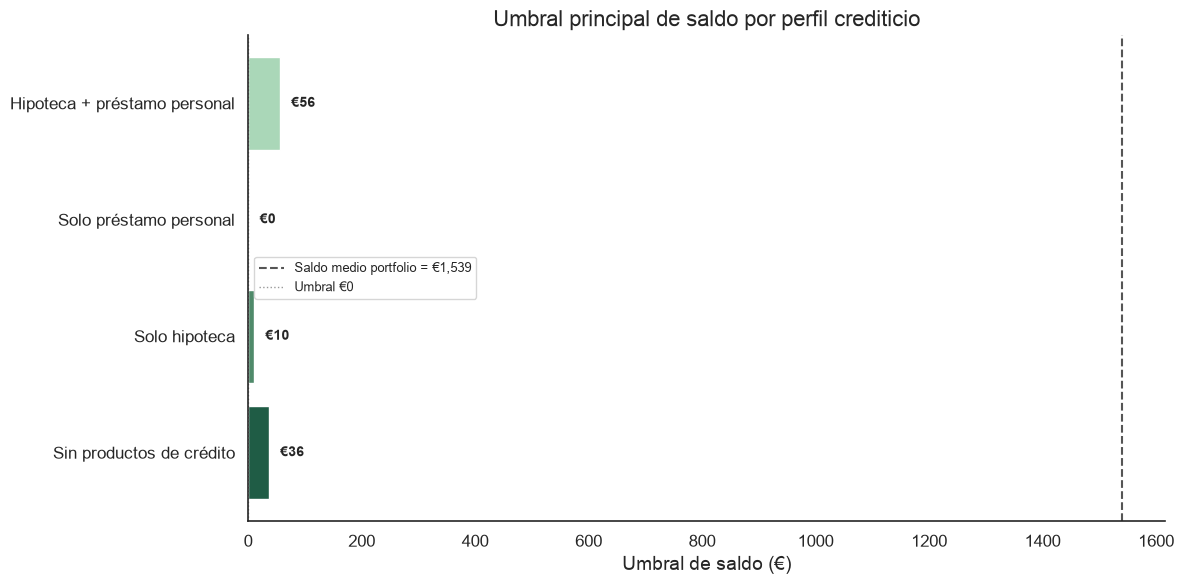

In [74]:
fig, ax = plt.subplots(figsize=(12, 6))

main_thresholds = compare_df["Umbral principal (€)"].values
profiles = compare_df["Perfil crediticio"].values
colors = COLORS[:4]

bars = ax.barh(profiles, main_thresholds, color=colors, edgecolor="white")
ax.axvline(PORTFOLIO_MEAN_BALANCE, color="#555555", linestyle="--", linewidth=1.5,
           label=f"Saldo medio portfolio = €{PORTFOLIO_MEAN_BALANCE:,.0f}")
ax.axvline(0, color="#999999", linestyle=":", linewidth=1, label="Umbral €0")

for bar, val in zip(bars, main_thresholds):
    ax.text(val + 20, bar.get_y() + bar.get_height() / 2, f"€{val:,.0f}",
            va="center", fontsize=10, fontweight="bold")

ax.set_title("Umbral principal de saldo por perfil crediticio")
ax.set_xlabel("Umbral de saldo (€)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### 6. Interpretación estadística

| Perfil crediticio | Umbral principal | Morosidad saldo ≤ €0 |
|---|---:|---:|
| Sin productos de crédito | ~€37 | 4,47% |
| Solo hipoteca | ~€18 | 6,60% |
| Solo préstamo personal | ~€0 | **19,33%** |
| Hipoteca + préstamo personal | ~€56 | 6,97% |

Los umbrales **no son homogéneos**: varían entre €0 y €106 según el perfil. El patrón común es que **saldo ≤ €0** concentra el mayor riesgo en todos los perfiles.

### 7. Interpretación de negocio

- **Solo préstamo personal:** umbral crítico en **€0** — cualquier saldo negativo implica riesgo extremo (19,33%).
- **Hipoteca + préstamo personal:** umbral en torno a **€56** — clientes con ambos productos y saldo bajo requieren monitorización reforzada.
- **Sin productos de crédito:** umbral más alto (~€86–€120), coherente con menor presión crediticia.

Las reglas de alerta deben ser **diferenciadas por perfil crediticio**, no un único corte global.

### 8. Conclusión del bloque

Los umbrales **difieren entre perfiles**, aunque **€0** emerge como umbral universal de alto riesgo. Los perfiles con préstamo personal presentan los puntos de corte más restrictivos.


## 5. Validación estadística


### 5.1 Validación de los umbrales

Se aplica **Chi-cuadrado** para comprobar que los segmentos de saldo (umbrales operativos definidos en WK2: €0, €500, €1.500, €3.000) presentan tasas de morosidad significativamente distintas.


In [75]:
contingency = pd.crosstab(df["balance_segment"], df["morosidad_flag"])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print("Resultados del Test Chi-cuadrado — Segmentos de saldo × Morosidad")
print(f"  χ² statistic  : {chi2:.2f}")
print(f"  gl            : {dof}")
print(f"  p-value       : {p_chi2:.2e}")
print(f"  Decisión      : {'Rechazar H₀ — segmentos difieren significativamente' if p_chi2 < 0.05 else 'No rechazar H₀'}")
print("\nTabla de contingencia:")
display(contingency)


Resultados del Test Chi-cuadrado — Segmentos de saldo × Morosidad
  χ² statistic  : 368.02
  gl            : 4
  p-value       : 2.25e-78
  Decisión      : Rechazar H₀ — segmentos difieren significativamente

Tabla de contingencia:


morosidad_flag,0,1
balance_segment,,
Negativo (≤ €0),1326,100
€0–500,3763,49
€500–1.500,2648,10
€1.500–3.000,1515,1
> €3.000,1562,1


### 5.2 Resumen estadístico


In [76]:
stat_summary = pd.DataFrame([
    {
        "Test": "Mann–Whitney U",
        "Hipótesis": "H₀: distribuciones de saldo iguales con/sin morosidad",
        "p-value": f"{p_mw:.2e}",
        "Decisión": "Rechazar H₀",
        "Interpretación": "Saldo difiere significativamente según Morosidad",
    },
    {
        "Test": "Correlación punto-biserial",
        "Hipótesis": "H₀: r = 0 (sin correlación saldo-morosidad)",
        "p-value": f"{p_pb:.2e}",
        "Decisión": "Rechazar H₀",
        "Interpretación": "Correlación negativa débil pero significativa (r = −0,061)",
    },
    {
        "Test": "Regresión logística",
        "Hipótesis": "H₀: coeficiente saldo = 0",
        "p-value": "< 0,001",
        "Decisión": "Rechazar H₀",
        "Interpretación": "Mayor saldo → menor probabilidad de morosidad",
    },
    {
        "Test": "Chi-cuadrado",
        "Hipótesis": "H₀: segmento de saldo y Morosidad independientes",
        "p-value": f"{p_chi2:.2e}",
        "Decisión": "Rechazar H₀",
        "Interpretación": "Los intervalos de saldo presentan morosidad significativamente distinta",
    },
])

print("Tabla 5.1 — Resumen de validación estadística")
display(stat_summary)


Tabla 5.1 — Resumen de validación estadística


,Test,Hipótesis,p-value,Decisión,Interpretación
0,Mann–Whitney U,H₀: distribuciones de saldo iguales con/sin mo...,4.97e-54,Rechazar H₀,Saldo difiere significativamente según Morosidad
1,Correlación punto-biserial,H₀: r = 0 (sin correlación saldo-morosidad),2.06e-10,Rechazar H₀,Correlación negativa débil pero significativa ...
2,Regresión logística,H₀: coeficiente saldo = 0,"< 0,001",Rechazar H₀,Mayor saldo → menor probabilidad de morosidad
3,Chi-cuadrado,H₀: segmento de saldo y Morosidad independientes,2.25e-78,Rechazar H₀,Los intervalos de saldo presentan morosidad si...


## 6. Conclusiones

### 6.1 Respuesta directa a la pregunta de negocio

**¿Qué umbrales de saldo indican mayor riesgo de morosidad?**

Los umbrales operativos identificados, validados estadísticamente, son:

| Umbral | Tasa morosidad (lado de riesgo) | Acción recomendada |
|---|---:|---|
| **Saldo ≤ €0** | 7,01% (4,8× media portfolio) | Alerta roja — revisión inmediata |
| **Saldo ≤ €106** | ~3,5% | Alerta ámbar — monitorización reforzada |
| **Saldo ≤ €340** | ~1,1% | Precaución — seguimiento periódico |
| **Saldo > €1.415** | < 0,2% | Zona de bajo riesgo |

Estos umbrales **no son uniformes** para todos los perfiles crediticios:
- **Solo préstamo personal:** umbral crítico en **€0** (morosidad 19,33% con saldo negativo).
- **Hipoteca + préstamo personal:** umbral en torno a **€56**.
- **Sin productos de crédito:** umbral más elevado (~€86), coherente con menor carga crediticia.

### 6.2 Hallazgos principales

1. **Relación saldo-morosidad confirmada** (Mann–Whitney p < 0,001; r = −0,061).
2. **Gradiente de riesgo:** Q1 (saldo más bajo) = 5,51% morosidad vs Q5 = 0,09%.
3. **Umbrales automáticos** del árbol: €0, €106, €340 y €1.415 como puntos de inflexión.
4. **Segmento crítico universal:** saldo ≤ €0 concentra la mayor morosidad en todos los perfiles.
5. **Perfil crediticio modula el riesgo:** Solo préstamo personal amplifica el efecto de saldos bajos.
6. **Chi-cuadrado** (p < 0,001) valida que los intervalos de saldo tienen morosidad significativamente distinta.


## 7. Recomendaciones de negocio

### Política de alertas por umbral de saldo

| Nivel | Condición | Acción |
|---|---|---|
| 🔴 Rojo | Saldo ≤ €0 | Bloqueo de nuevas concesiones; contacto proactivo de cobros |
| 🟠 Ámbar | €0 < Saldo ≤ €106 | Revisión trimestral obligatoria; límite de exposición reducido |
| 🟡 Precaución | €106 < Saldo ≤ €340 | Monitorización estándar con alerta automática si cae de nivel |
| 🟢 Verde | Saldo > €340 | Operativa normal; revisión anual |

### Reglas diferenciadas por perfil crediticio

- **Solo préstamo personal:** aplicar umbral **€0** como criterio de bloqueo automático (morosidad 19,33% en saldo negativo).
- **Hipoteca + préstamo personal:** alerta a partir de **€56** de saldo.
- **Solo hipoteca / Sin productos:** mantener umbrales estándar con revisión en **€0**.

### Integración en scoring crediticio

- Incorporar `balance_segment` y `credit_profile` como variables obligatorias en el motor de scoring.
- Actualizar umbrales trimestralmente con datos frescos.
- Priorizar monitorización de clientes en Q1 de saldo (quintil inferior) con cualquier perfil crediticio activo.

### Próximos pasos (WK4)

1. Desarrollar modelo predictivo multivariante (regresión logística / árbol) incluyendo variables temporales.
2. Backtesting de las reglas de umbral sobre datos históricos.
3. Integración con sistemas core bancarios para alertas automáticas.

---

*Informe elaborado por Equip_32 — Analistas de Finanzas y Riesgo Crediticio. WK3 — Simulador Empresarial IT Academy.*
